In [35]:
import math as mt
import numpy as np
import matplotlib.pylab as pl

In [97]:
def TriangularSuperior(M,v):
    A = np.copy(M)
    b = np.copy(v)
    for i in range(4):
        b[i] = b[i]/A[i][i]
        A[i] = A[i]/A[i][i]
        for j in range(i+1,4):
            b[j] = b[j] - (A[j][i])*b[i]
            A[j] = A[j] - (A[j][i])*A[i]
    return A,b

In [98]:
x = np.zeros(4)
A = [[2,1,4,1],
     [3,4,-1,-1],
     [1,-4,1,3],
     [2,-2,1,3]]
A = np.array(A,float)
b = np.array([-4,3,9,7],float)

A1,b1 = TriangularSuperior(A,b)
print(A1)
b1

[[ 1.          0.5         2.          0.5       ]
 [ 0.          1.         -2.8        -1.        ]
 [-0.         -0.          1.          0.14705882]
 [ 0.          0.          0.          1.        ]]


array([-2.        ,  3.6       , -2.        , -1.47826087])

In [99]:
x[3] = b1[3]
x[2] = b1[2] - x[3]*A1[2][3]
x[1] = b1[1] - x[2]*A1[1][2] - x[3]*A1[1][3]
x[0] = b1[0] - x[1]*A1[0][1] - x[2]*A1[0][2] - x[3]*A1[0][3]
x

array([ 3.73913043, -2.86956522, -1.7826087 , -1.47826087])

In [100]:
np.dot(A,x)

array([-4.,  3.,  9.,  7.])

In [101]:
x = np.zeros(4)

for i in range(3,-1,-1):
    s = 0
    for j in range(3,-1,-1):
        s = s + x[j]*A1[i][j]
    x[i] = b1[i] - s
x

array([ 3.73913043, -2.86956522, -1.7826087 , -1.47826087])

In [102]:
np.dot(A,x)

array([-4.,  3.,  9.,  7.])

Solución de clase

In [119]:
N = 4

x = np.zeros(4)
for i in range(N-1,-1,-1):
    x[i] = b1[i]
    for j  in range(i+1,N):
        x[i] = x[i] - x[j]*A1[i][j]
x

array([ 3.73913043, -2.86956522, -1.7826087 , -1.47826087])

In [120]:
np.dot(A,x)

array([-4.,  3.,  9.,  7.])

### Método de relajación

In [76]:
def f(x):
    return np.exp(1-x**2)

In [65]:
X = []
n = []
x = 1/2
for i in range(100):
    a = f(x)
    x = a
    X.append(x)
    n.append(i)
x

0.0016799111166579221

In [67]:
f(1)

1.0

In [68]:
f(0)

2.718281828459045

In [23]:
mt.exp(1)

2.718281828459045

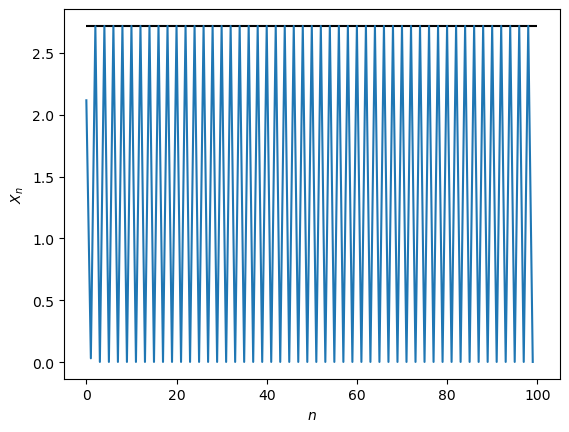

In [66]:
pl.xlabel(r'$n$')
pl.ylabel(r'$X_n$')
pl.hlines(xmin =0.0, xmax=100, y=mt.exp(1),color='black')
pl.plot(n,X)

/tmp/ipykernel_4494/2277975746.py:2: RuntimeWarning: divide by zero encountered in log
  return np.sqrt(1-np.log(x))
/tmp/ipykernel_4494/2277975746.py:2: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(1-np.log(x))


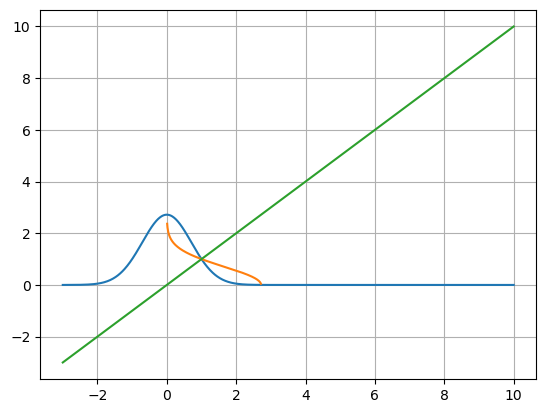

In [91]:
y = np.linspace(-3,10,1000)
g = f(y)
u = np.linspace(0,10,1000)
t = h(u)

pl.plot(y,g)
pl.plot(u,t)
pl.plot(y,y)
pl.grid()

In [85]:
xn = 0.25 # = x0
for i in range(10):
    xn = f(xn)
    print('xn =',xn)

xn = 2.553589458062927
xn = 0.004002568014112948
xn = 2.7182382804360072
xn = 0.0016802388060210747
xn = 2.7182741542099733
xn = 0.0016799111439932206
xn = 2.7182741572027753
xn = 0.0016799111166602065
xn = 2.718274157203025
xn = 0.0016799111166579267


In [86]:
def h(x):
    return np.sqrt(1-np.log(x))

In [87]:
h(1)

1.0

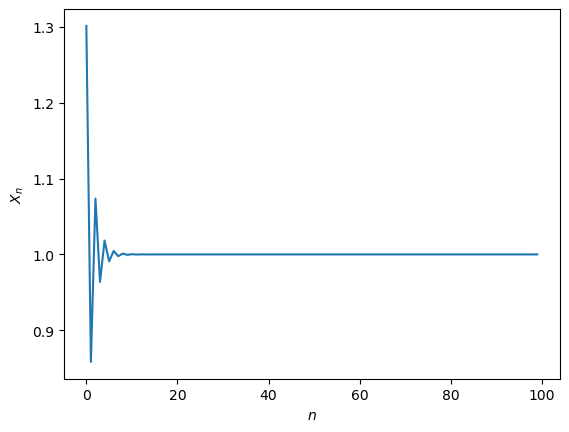

In [96]:
H = []
n = []
x = 1/2
for i in range(100):
    a = h(x)
    x = a
    H.append(x)
    n.append(i)
    
pl.xlabel(r'$n$')
pl.ylabel(r'$X_n$')
# pl.hlines(xmin =0.0, xmax=100, y=mt.exp(1),color='black')
pl.plot(n,H)

In [94]:
xn = 0.25 # = x0
for i in range(100):
    xn = h(xn)
    print("i =",i,'xn =',xn)

i = 0 xn = 1.544763529191407
i = 1 xn = 0.7517507279038896
i = 2 xn = 1.1337329883331286
i = 3 xn = 0.9351386434337955
i = 4 xn = 1.03298619494102
i = 5 xn = 0.9836392499271658
i = 6 xn = 1.0082142952158581
i = 7 xn = 0.9959012292821243
i = 8 xn = 1.0020514925403659
i = 9 xn = 0.9989747789093033
i = 10 xn = 1.0005127420424547
i = 11 xn = 0.9997436618277855
i = 12 xn = 1.0001281773015194
i = 13 xn = 0.9999359134026986
i = 14 xn = 1.0000320438120647
i = 15 xn = 0.999983978222315
i = 16 xn = 1.0000080109209302
i = 17 xn = 0.9999959945475567
i = 18 xn = 1.000002002728227
i = 19 xn = 0.9999989986363879
i = 20 xn = 1.0000005006819315
i = 21 xn = 0.9999997496590656
i = 22 xn = 1.000000125170475
i = 23 xn = 0.9999999374147645
i = 24 xn = 1.0000000312926183
i = 25 xn = 0.999999984353691
i = 26 xn = 1.0000000078231546
i = 27 xn = 0.9999999960884227
i = 28 xn = 1.0000000019557886
i = 29 xn = 0.9999999990221057
i = 30 xn = 1.000000000488947
i = 31 xn = 0.9999999997555264
i = 32 xn = 1.000000000122

### 3. Descomposición LU (valor: 2 puntos).